Import Library

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

Load Data

In [ ]:
df = pd.read_csv('fact_transaction_bank_jago-2.csv')
df.head()

,transaction_id,customer_id,customer_name,product_id,transaction_date,transaction_amount,transaction_type,channel
0,TRX00000001,CUST003572,Indah Kusuma,PROD0030,2024-05-01,2341008,Transfer,Mobile App
1,TRX00000002,CUST004585,Sari Lestari,PROD0004,2024-06-09,5830638,Payment,Branch
2,TRX00000003,CUST003725,Citra Saputra,PROD0039,2022-08-23,9079360,Payment,ATM
3,TRX00000004,CUST000165,Lia Putri,PROD0050,2022-12-28,3856256,Top Up,Mobile App
4,TRX00000005,CUST004091,Fajar Putri,PROD0015,2024-07-14,1839195,Transfer,Mobile App


 Data Cleaning

In [ ]:
df = df.dropna()
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_amount'] = df['transaction_amount'].astype(float)

Feature Engineering (Customer KPI)

In [ ]:
customer_df = df.groupby('customer_id').agg(
    total_transaction=('transaction_id', 'count'),
    total_amount=('transaction_amount', 'sum'),
    avg_transaction=('transaction_amount', 'mean')
).reset_index()

customer_df.head()

,customer_id,total_transaction,total_amount,avg_transaction
0,CUST000001,1,9757821.0,9757821.0
1,CUST000002,3,3557025.0,1185675.0
2,CUST000003,1,1558401.0,1558401.0
3,CUST000004,4,23978614.0,5994653.5
4,CUST000005,6,27765381.0,4627563.5


Scaling Data

In [ ]:
features = customer_df[['total_transaction', 'total_amount', 'avg_transaction']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Elbow Method

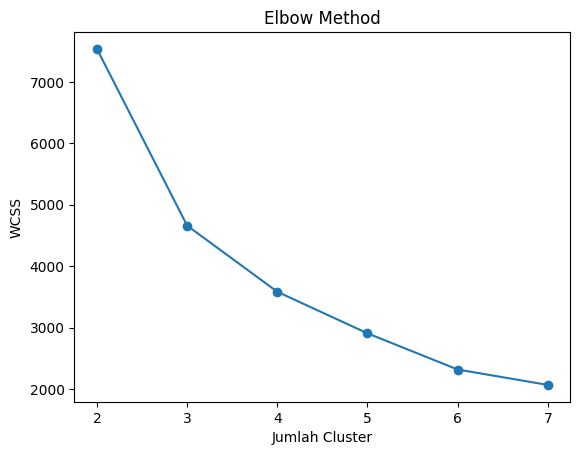

In [ ]:
wcss = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 8), wcss, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df['cluster'] = kmeans.fit_predict(scaled_features)

customer_df.head()

,customer_id,total_transaction,total_amount,avg_transaction,cluster
0,CUST000001,1,9757821.0,9757821.0,2
1,CUST000002,3,3557025.0,1185675.0,0
2,CUST000003,1,1558401.0,1558401.0,0
3,CUST000004,4,23978614.0,5994653.5,1
4,CUST000005,6,27765381.0,4627563.5,1


Evaluasi Clustering

In [ ]:
score = silhouette_score(scaled_features, customer_df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.4110544302392155


Interpretasi Cluster

In [ ]:
cluster_profile = customer_df.groupby('cluster')[[
    'total_transaction',
    'total_amount',
    'avg_transaction'
]].mean()

cluster_profile

,total_transaction,total_amount,avg_transaction
cluster,,,
0,1.712230,5.160775e+06,2.947189e+06
1,3.757102,2.007889e+07,5.416854e+06
2,1.521455,1.056440e+07,7.108663e+06


In [ ]:
customer_df[['customer_id', 'cluster']].to_csv(
    'customer_segmentation_result.csv',
    index=False
)
